In [1]:
#importing the Libraries 
from imports import *

# Reading the dataset using pandas library...
df=pd.read_csv("C:\\Users\\suman\\Downloads\\ML Documents\\market_sales.csv")
df.head()

,TV_Ad_Spend,Social_Media_Spend,Discount_Offers,Search_Engine_Marketing_Spend,Product_Category,Region,Customer_Segment,Website_Traffic,Conversion_Rate,Sales
0,22483.0,17282.0,30.0,10516,Electronics,East,Budget,1000,2.11,96119
1,19308.0,18872.0,5.0,10413,Home Appliances,North,Budget,1000,2.15,82430
2,23238.0,13674.0,15.0,5715,Home Appliances,East,Mid-tier,1000,3.50,115771
3,27615.0,12551.0,20.0,10844,FMCG,South,Mid-tier,1825,2.14,83833
4,18829.0,10659.0,15.0,14564,Sports,East,Mid-tier,1000,2.55,103896


In [2]:
#checking the shape of the dataframe...
df.shape

(2500, 10)

In [3]:
#checking the dataset information...
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   TV_Ad_Spend                    2405 non-null   float64
 1   Social_Media_Spend             2344 non-null   float64
 2   Discount_Offers                2318 non-null   float64
 3   Search_Engine_Marketing_Spend  2500 non-null   int64  
 4   Product_Category               2333 non-null   object 
 5   Region                         2373 non-null   object 
 6   Customer_Segment               2500 non-null   object 
 7   Website_Traffic                2500 non-null   int64  
 8   Conversion_Rate                2500 non-null   float64
 9   Sales                          2500 non-null   int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 195.4+ KB


In [4]:
#checking the count,mean,std,min,max and other statistical values of the dataset...
df.describe()

,TV_Ad_Spend,Social_Media_Spend,Discount_Offers,Search_Engine_Marketing_Spend,Website_Traffic,Conversion_Rate,Sales
count,2405.000000,2344.000000,2318.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,20154.879834,14921.009812,14.309750,11900.040400,1175.940000,2.136004,83898.009200
std,4893.791754,4038.474895,8.885829,3577.258013,282.022437,0.645222,27916.528551
min,5000.000000,3000.000000,0.000000,2000.000000,1000.000000,0.500000,18747.000000
25%,16884.000000,12215.750000,10.000000,9479.750000,1000.000000,1.670000,63358.750000
50%,20126.000000,15007.500000,15.000000,11856.500000,1000.000000,2.090000,81320.500000
75%,23362.000000,17555.750000,20.000000,14394.250000,1279.000000,2.540000,101064.000000
max,39263.000000,30000.000000,30.000000,24351.000000,2542.000000,4.750000,221038.000000


In [5]:
#checking the statistical values of the object type columns in the dataset...
df.describe(include='object')

,Product_Category,Region,Customer_Segment
count,2333,2373,2500
unique,5,4,3
top,Fashion,East,Mid-tier
freq,508,608,868


In [6]:
#checking the duplicate values in the dataset...
df.duplicated(keep='first').sum()
#keep='first' will keep the first occurrence of the duplicate value and will mark the rest as duplicate.
#keep=False will mark all the occurrences of the duplicate value as duplicate.(its a keyword so write like this only...)
#keep='last' will keep the last occurrence of the duplicate value and will mark the rest

np.int64(0)

In [7]:
#dropping the duplicate values in the dataset...
#df.drop_duplicates(inplace=True)

In [8]:

#unique will shows the unique names of variables in the dataset...
#nunique will shows the count of unique names of variables in the dataset...
df.nunique()
#df['Product_Category'].unique()

TV_Ad_Spend                      2240
Social_Media_Spend               2174
Discount_Offers                     7
Search_Engine_Marketing_Spend    2249
Product_Category                    5
Region                              4
Customer_Segment                    3
Website_Traffic                   655
Conversion_Rate                   317
Sales                            2472
dtype: int64

In [9]:
# Sorting the null values in the dataset in descending order...
df.isnull().sum().sort_values(ascending=False)

Discount_Offers                  182
Product_Category                 167
Social_Media_Spend               156
Region                           127
TV_Ad_Spend                       95
Search_Engine_Marketing_Spend      0
Customer_Segment                   0
Website_Traffic                    0
Conversion_Rate                    0
Sales                              0
dtype: int64

In [10]:
# Checking the Numeric columns in the dataset...
numeric_features = df.select_dtypes(include=[np.number])
numeric_features.columns

Index(['TV_Ad_Spend', 'Social_Media_Spend', 'Discount_Offers',
       'Search_Engine_Marketing_Spend', 'Website_Traffic', 'Conversion_Rate',
       'Sales'],
      dtype='object')

In [11]:
#filling the numerical null values in the dataset...
df['TV_Ad_Spend'].fillna(df['TV_Ad_Spend'].mean(),inplace=True)
df['Social_Media_Spend'].fillna(df['Social_Media_Spend'].mean(),inplace=True)
df['Discount_Offers'].fillna(df['Discount_Offers'].mean(),inplace=True)

In [12]:
# Checking the Categorical columns in the dataset...
categorical_features = df.select_dtypes(include=['object'])
categorical_features.columns

Index(['Product_Category', 'Region', 'Customer_Segment'], dtype='object')

In [13]:
#filling the categorical null values in the dataset...
df['Product_Category'].fillna(df['Product_Category'].mode()[0],inplace=True)
df['Region'].fillna(df['Region'].mode()[0],inplace=True)

In [14]:
# to check the null values after filling the null values in the dataset...
df.isnull().sum()

TV_Ad_Spend                      0
Social_Media_Spend               0
Discount_Offers                  0
Search_Engine_Marketing_Spend    0
Product_Category                 0
Region                           0
Customer_Segment                 0
Website_Traffic                  0
Conversion_Rate                  0
Sales                            0
dtype: int64

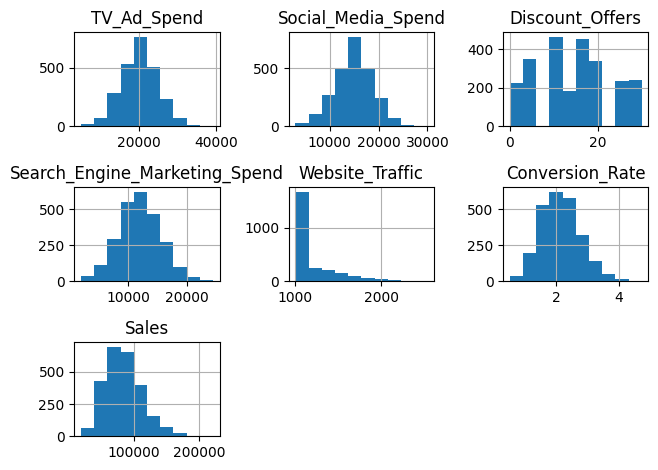

In [15]:
#Applying univariate analysis on the dataset...
df.hist()
plt.tight_layout()
plt.show()

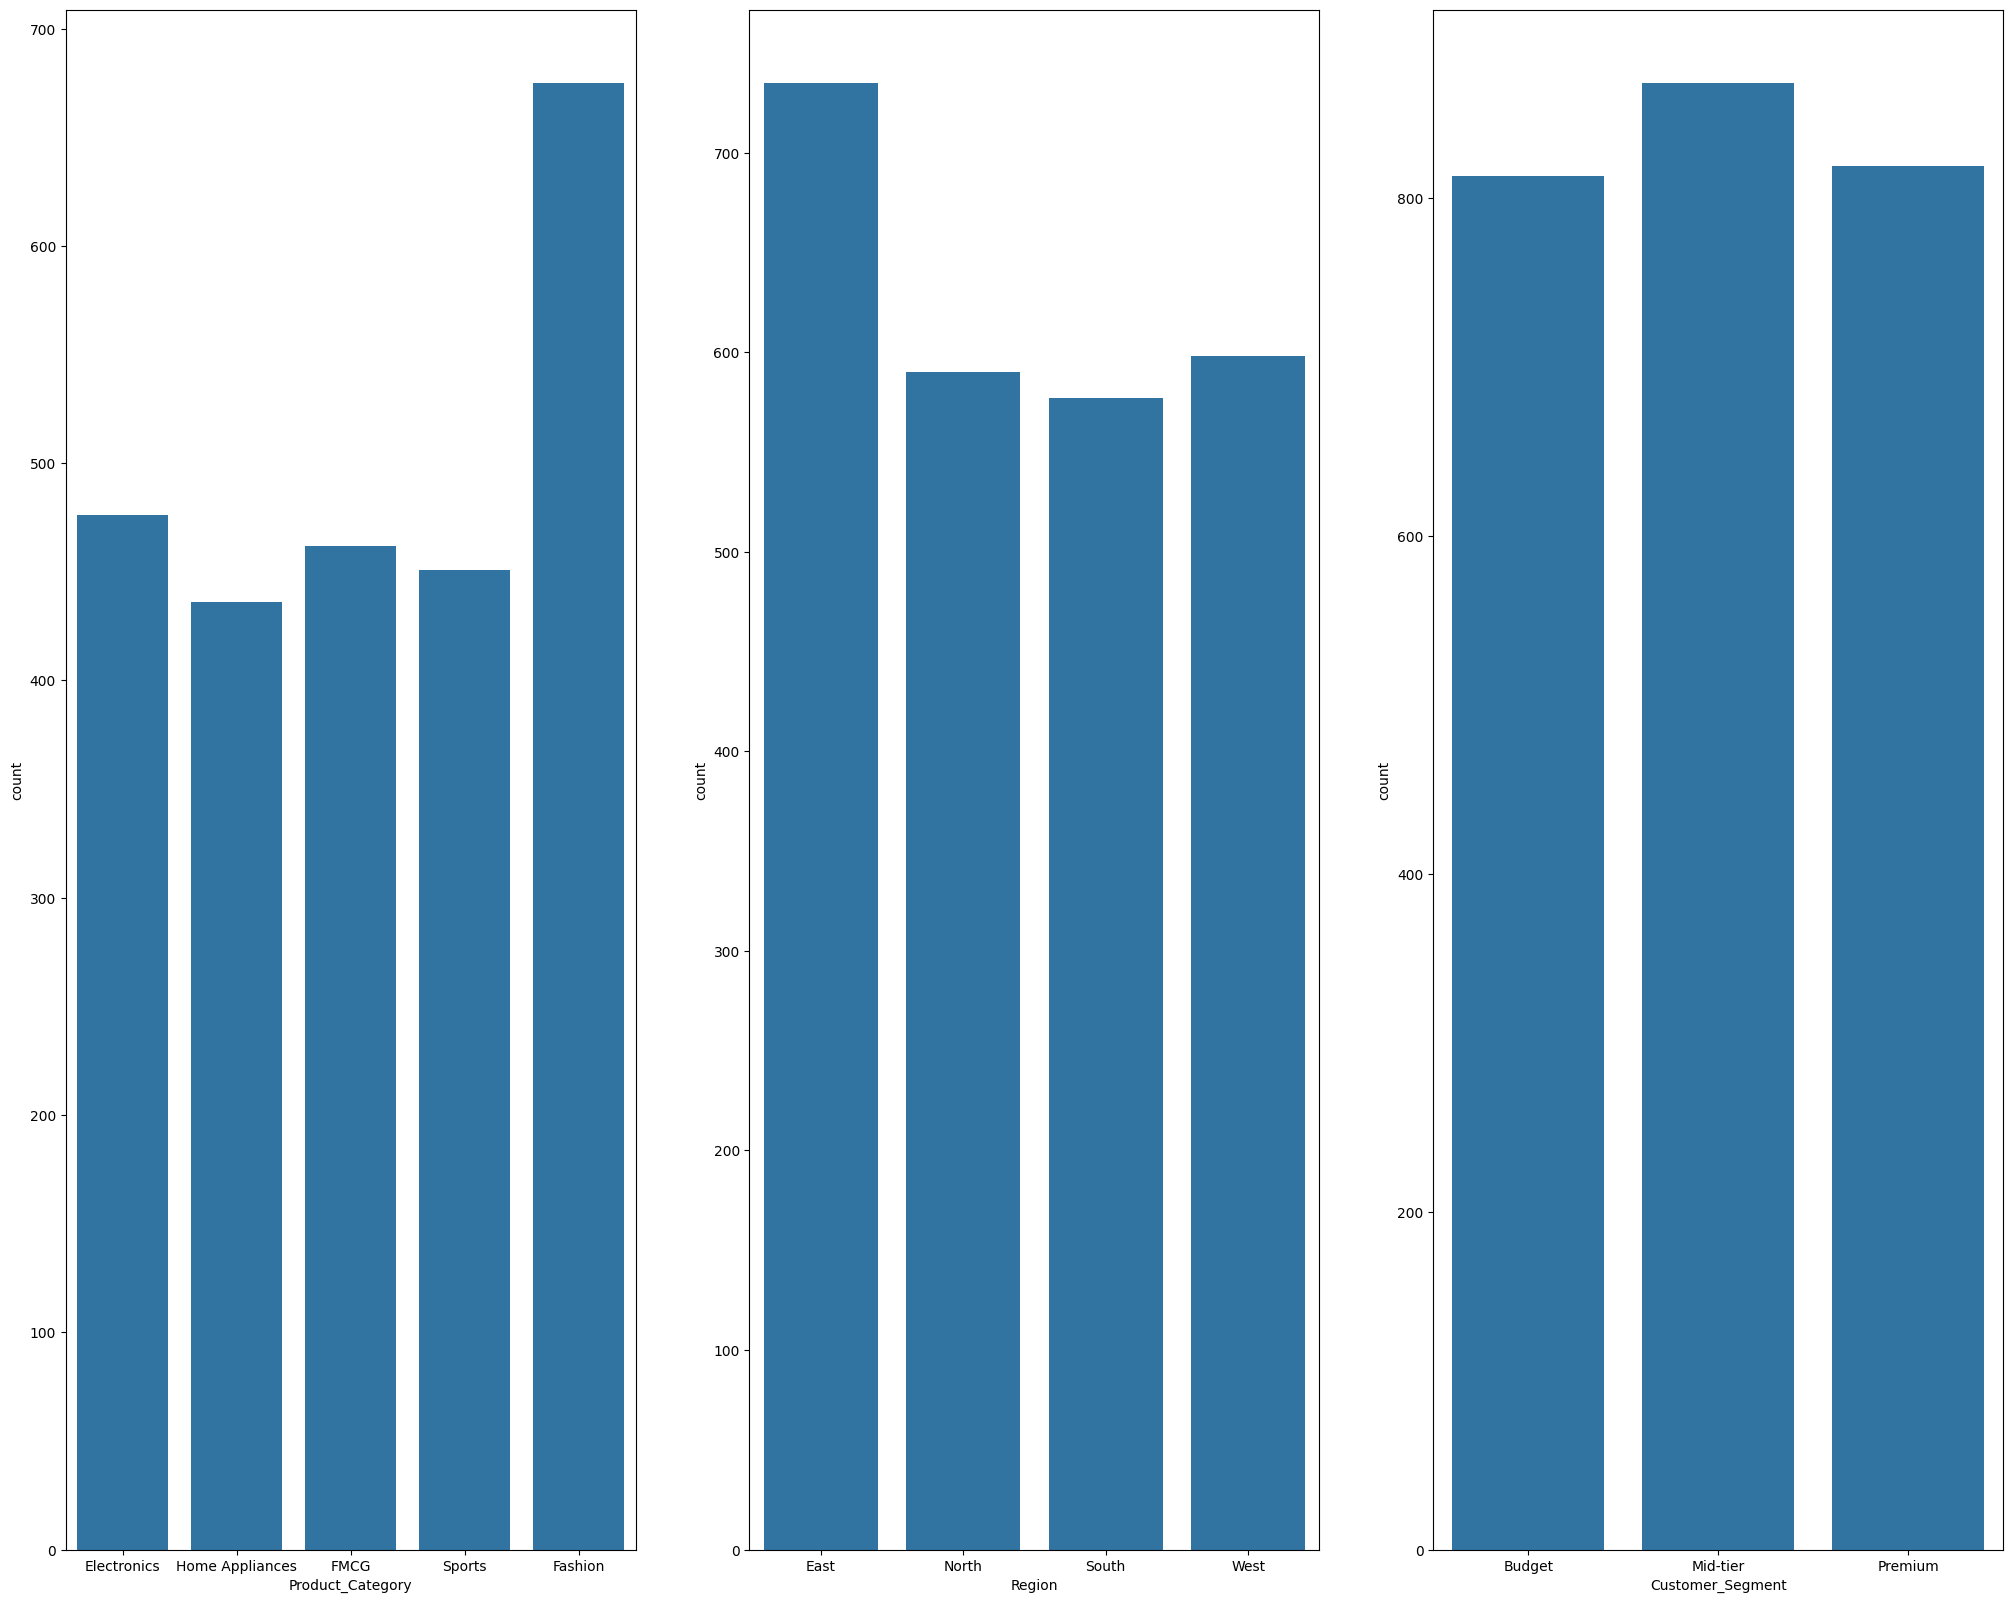

In [16]:
#EDA - Univariate Analysis on the dataset for the categorical columns...
fig, ax = plt.subplots(1,3, figsize=(25,20))
# using for loop to plot the count plot for each variable in the categorical features...
for variable, subplot in zip(categorical_features, ax.flatten()):
    #use countplot to plot the graph
    sns.countplot(x=variable, data=df, ax=subplot)
plt.show()

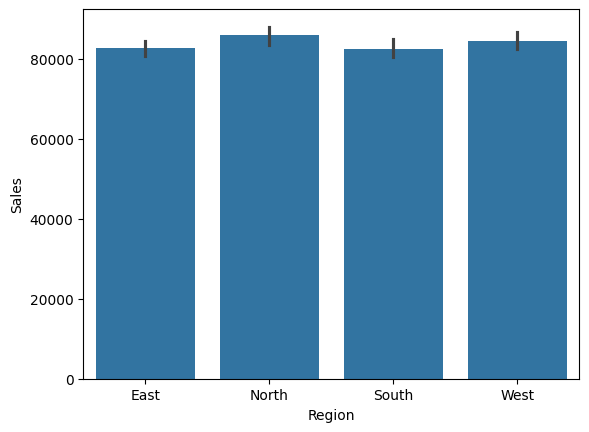

In [17]:
#Bivariate Analysis on the dataset...
sns.barplot(x='Region', y='Sales', data=df)
plt.show()

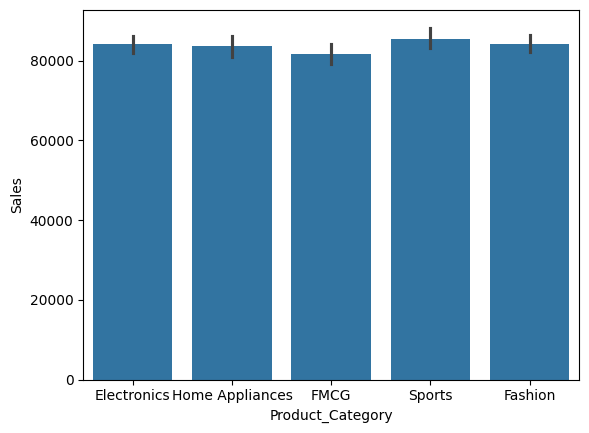

In [18]:
#based on the product category and Sales on the data set...
sns.barplot(x='Product_Category', y='Sales', data=df)   
plt.show()

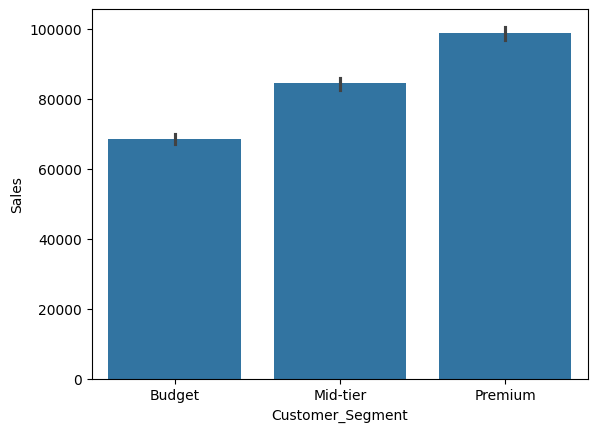

In [19]:
#Based on customer segment and sales on the dataset...
sns.barplot(x='Customer_Segment', y='Sales', data=df)   
plt.show()

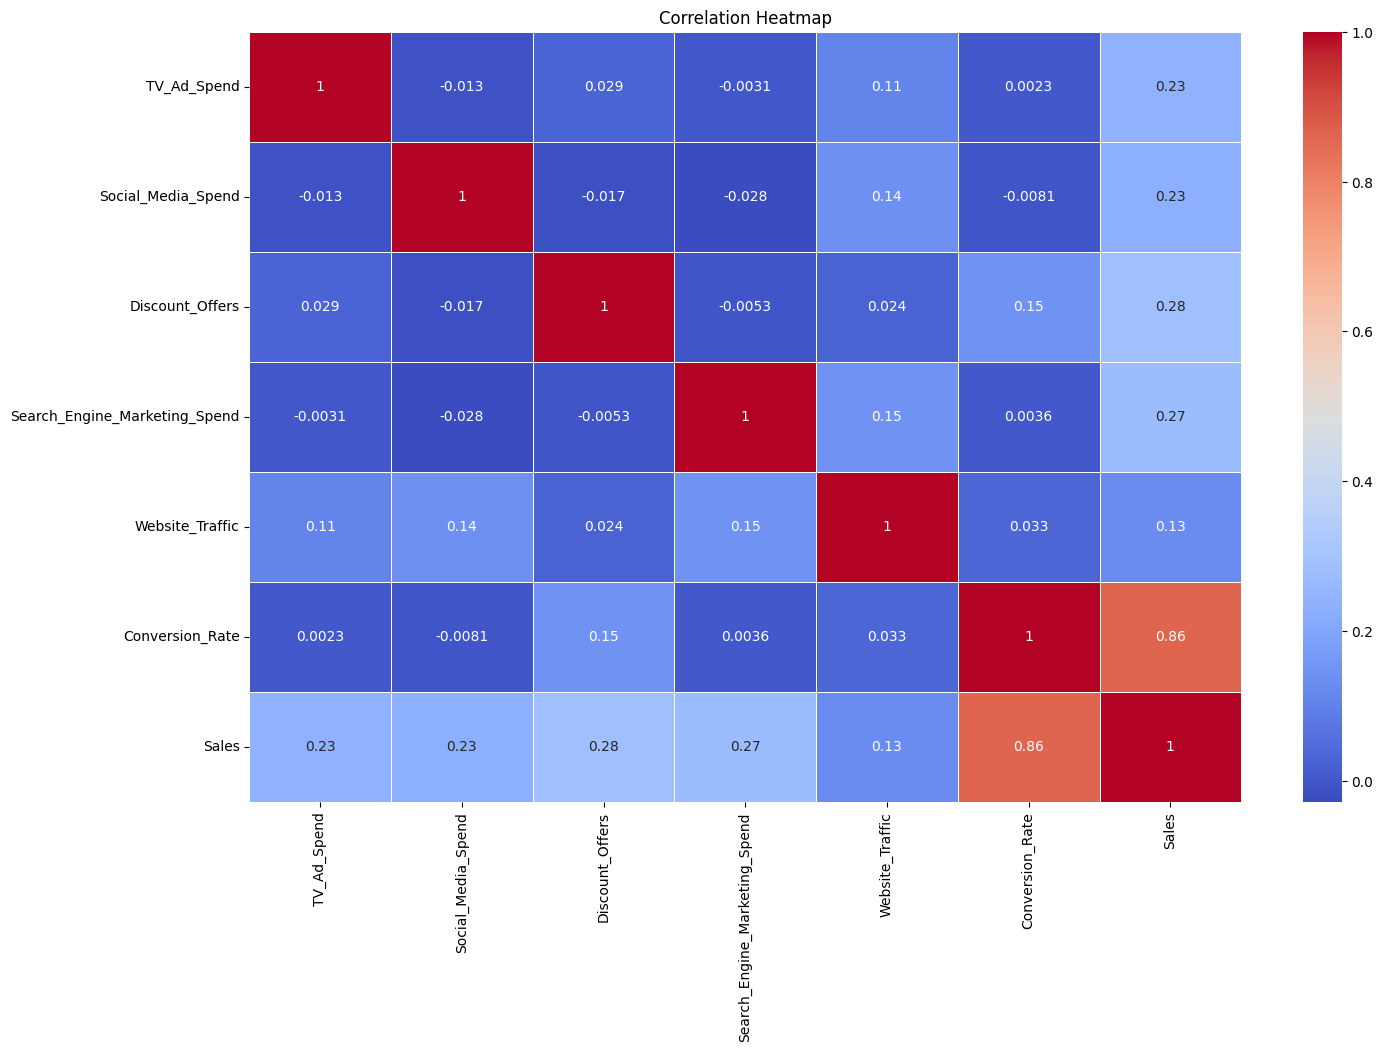

In [20]:
# Multivariate Analysis on the dataset..
#numeric_df = df[numeric_features]
#checking the correlation coefficient to see the relationship between the numerical variables in the dataset...
plt.figure(figsize=(16,10))
sns.heatmap(numeric_features.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')    
plt.show()

In [21]:
#dummy encoding the categorical variables in the dataset...
# to create the dummmy variables for the categorical features in the dataset and drop the first column to avoid the dummy variable trap...
# to create (n-1) dummy variables we can use the drop_first=True parameter in the get_dummies function. This will drop the first column of the dummy variables created for each categorical feature, thus avoiding the dummy variable trap.
df_encoded = pd.get_dummies(df, columns=categorical_features.columns, drop_first=True)


In [22]:
# to concatenate the dummy variables with the numerical variables in the dataset...
data_dummy = pd.concat([df_encoded, df[numeric_features.columns]], axis=1)
# display the data with dummy variables and numerical variables...
data_dummy.head()

,TV_Ad_Spend,Social_Media_Spend,Discount_Offers,Search_Engine_Marketing_Spend,Website_Traffic,Conversion_Rate,Sales,Product_Category_FMCG,Product_Category_Fashion,Product_Category_Home Appliances,...,Region_West,Customer_Segment_Mid-tier,Customer_Segment_Premium,TV_Ad_Spend,Social_Media_Spend,Discount_Offers,Search_Engine_Marketing_Spend,Website_Traffic,Conversion_Rate,Sales
0,22483.0,17282.0,30.0,10516,1000,2.11,96119,False,False,False,...,False,False,False,22483.0,17282.0,30.0,10516,1000,2.11,96119
1,19308.0,18872.0,5.0,10413,1000,2.15,82430,False,False,True,...,False,False,False,19308.0,18872.0,5.0,10413,1000,2.15,82430
2,23238.0,13674.0,15.0,5715,1000,3.50,115771,False,False,True,...,False,True,False,23238.0,13674.0,15.0,5715,1000,3.50,115771
3,27615.0,12551.0,20.0,10844,1825,2.14,83833,True,False,False,...,False,True,False,27615.0,12551.0,20.0,10844,1825,2.14,83833
4,18829.0,10659.0,15.0,14564,1000,2.55,103896,False,False,False,...,False,True,False,18829.0,10659.0,15.0,14564,1000,2.55,103896


In [23]:
# generating intercept term and seperating the dependent and independent variables in the dataset...
data_dummy = sm.add_constant(data_dummy)
X = data_dummy.drop('Sales', axis=1)  # Independent variables (features)
y = pd.DataFrame(df['Sales'])  # Dependent variable (target)
y.head()

,Sales
0,96119
1,82430
2,115771
3,83833
4,103896


In [24]:
from sklearn.model_selection import train_test_split
from statsmodels.tools.eval_measures import rmse
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [25]:
#splitting the dataset into training and testing sets...
# the proportion of the dataset to be included in the test split is specified by the test_size parameter. In this case, 30% of the dataset will be used for testing and 70% for training.
# random_state parameter is used to control the shuffling applied to the data before applying the split. It ensures that the same random split is generated each time the code is run, which can be useful for reproducibility and debugging purposes.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# printing the shape of the training and testing sets...
print("Shape of  X training set:", X_train.shape)
print("Shape of  X testing set:", X_test.shape)        
print("Shape of y training set:", y_train.shape)
print("Shape of y testing set:", y_test.shape)

Shape of  X training set: (1750, 22)
Shape of  X testing set: (750, 22)
Shape of y training set: (1750, 1)
Shape of y testing set: (750, 1)


In [26]:
# building the model using OLS regression...
linreg = sm.OLS(y_train['Sales'], X_train.astype(int)).fit()
print(linreg.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     582.8
Date:                Tue, 16 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:45:32   Log-Likelihood:                -18832.
No. Observations:                1750   AIC:                         3.770e+04
Df Residuals:                    1734   BIC:                         3.778e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   